In [125]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
import pycountry
import pandas as pd

countries = [c.name for c in pycountry.countries]

diet_df = pd.read_csv("../data/dietary-composition-by-country.csv")

diet_df = diet_df[diet_df["Entity"].isin(countries)]

In [127]:
unique_entities = set(diet_df["Entity"].unique())
print(unique_entities)

{'Slovenia', 'Jamaica', 'Nauru', 'Bosnia and Herzegovina', 'Serbia', 'Bulgaria', 'Saudi Arabia', 'Belize', 'Iraq', 'Slovakia', 'South Sudan', 'Montenegro', 'Vanuatu', 'Australia', 'Maldives', 'Romania', 'Honduras', 'Afghanistan', 'Haiti', 'New Zealand', 'Ghana', 'Marshall Islands', 'Saint Vincent and the Grenadines', 'United Arab Emirates', 'Finland', 'Qatar', 'Nicaragua', 'Guinea-Bissau', 'Rwanda', 'Uganda', 'Zimbabwe', 'El Salvador', 'Sri Lanka', 'Sweden', 'Portugal', 'Czechia', 'Burkina Faso', 'Congo', 'Germany', 'Philippines', 'Nigeria', 'North Macedonia', 'Italy', 'Benin', 'Cambodia', 'Mauritius', 'Guyana', 'Tajikistan', 'Tonga', 'Gabon', 'Lebanon', 'Myanmar', 'Hong Kong', 'Indonesia', 'Albania', 'Cuba', 'Samoa', 'Papua New Guinea', 'Trinidad and Tobago', 'Libya', 'Guatemala', 'Kuwait', 'Israel', 'Switzerland', 'Latvia', 'Seychelles', 'Sierra Leone', 'Malawi', 'Paraguay', 'Malta', 'United Kingdom', 'Senegal', 'Poland', 'Antigua and Barbuda', 'United States', 'Mali', 'Thailand', 'S

In [128]:
cols = diet_df.drop(columns=["Entity","Code","Year"]).columns
diet_df['Calories intake']= diet_df[cols].sum(axis=1)

In [129]:
meat_cols = [
    'Pork', 
    'Poultry meat', 
    'Beef and buffalo meat', 
    'Sheep and goat meat', 
    'Other meat'
]

plant_cols = [
    'Wheat', 'Rice', 'Maize', 'Barley', 'Other cereals', 
    'Vegetables', 'Fruit', 'Pulses', 'Nuts', 'Starchy roots', 
    'Sugar crops', 'Vegetable oils', 'Oilcrops'
]

In [130]:
diet_df[meat_cols + plant_cols] = diet_df[meat_cols + plant_cols].fillna(0)
diet_df['Meat Consumption'] = diet_df[meat_cols].sum(axis=1)
diet_df['Plant-based Consumption'] = diet_df[plant_cols].sum(axis=1)

In [131]:
diet_df_world = diet_df[diet_df['Entity'] == 'World'].sort_values('Year')


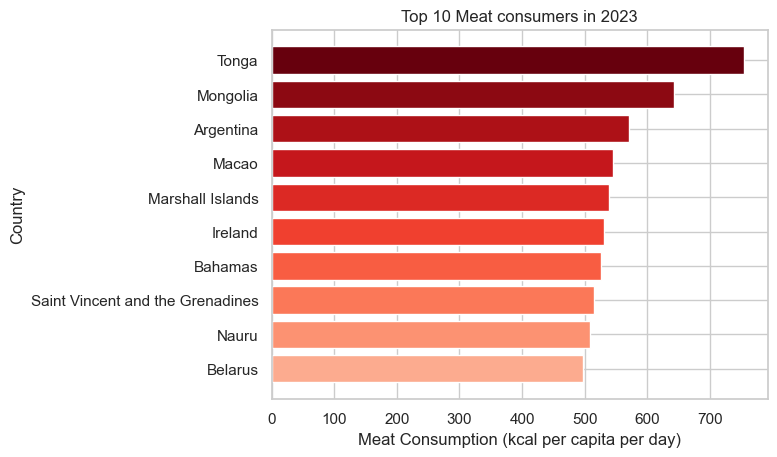

In [132]:
meat_consumers_2023 = diet_df[diet_df["Year"]==2023].sort_values(by="Meat Consumption",ascending=False)[:10]
top10_meat_consumers_2023 = meat_consumers_2023.head(10)
colors = plt.cm.Reds(np.linspace(1, 0.3, len(top10_meat_consumers_2023)))
plt.barh(top10_meat_consumers_2023["Entity"], top10_meat_consumers_2023["Meat Consumption"], color=colors)
plt.xlabel("Meat Consumption (kcal per capita per day)")
plt.ylabel("Country")
plt.title("Top 10 Meat consumers in 2023")
plt.gca().invert_yaxis()
plt.show()

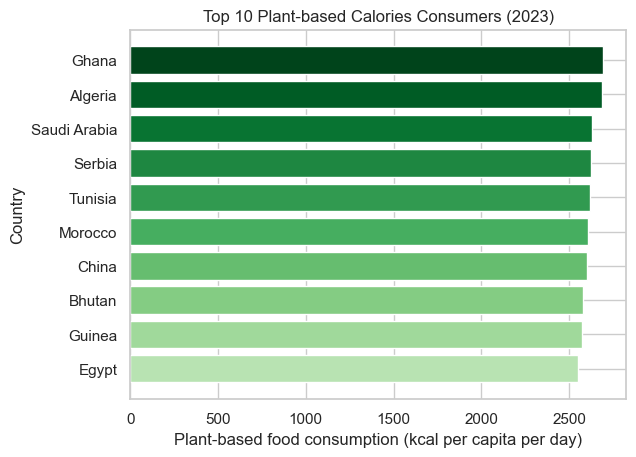

In [133]:
plant_consumers_2023 = diet_df[diet_df["Year"]==2023].sort_values(by="Plant-based Consumption",ascending=False)[:10]
top10_plant_consumers_2023 = plant_consumers_2023.head(10)
colors = plt.cm.Greens(np.linspace(1, 0.3, len(top10_plant_consumers_2023)))
plt.barh(top10_plant_consumers_2023["Entity"], top10_plant_consumers_2023["Plant-based Consumption"], color=colors)
plt.xlabel("Plant-based food consumption (kcal per capita per day)")
plt.ylabel("Country")
plt.title("Top 10 Plant-based Calories Consumers (2023)")
plt.gca().invert_yaxis()
plt.show()

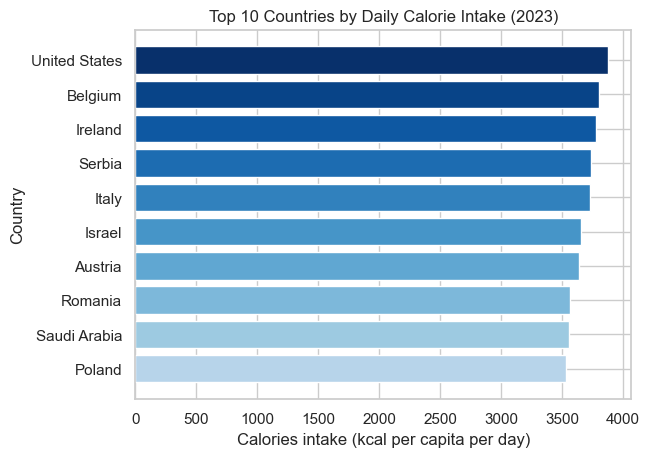

In [134]:
consumers_2023 = diet_df[diet_df["Year"]==2023].sort_values(by="Calories intake",ascending=False)[:10]
top10_consumers_2023 = consumers_2023.head(10)
colors = plt.cm.Blues(np.linspace(1, 0.3, len(top10_consumers_2023)))
plt.barh(top10_consumers_2023["Entity"], top10_consumers_2023["Calories intake"], color=colors)
plt.xlabel("Calories intake (kcal per capita per day)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Daily Calorie Intake (2023)")
plt.gca().invert_yaxis()
plt.show()

In [135]:
blue_zones_countries =["Greece","Italy","Japan","United States","Costa Rica"]
diet_df_bz= diet_df[diet_df["Entity"].isin(blue_zones_countries)]

In [136]:
diet_df_restofworld = diet_df[~(diet_df["Entity"].isin(blue_zones_countries))]

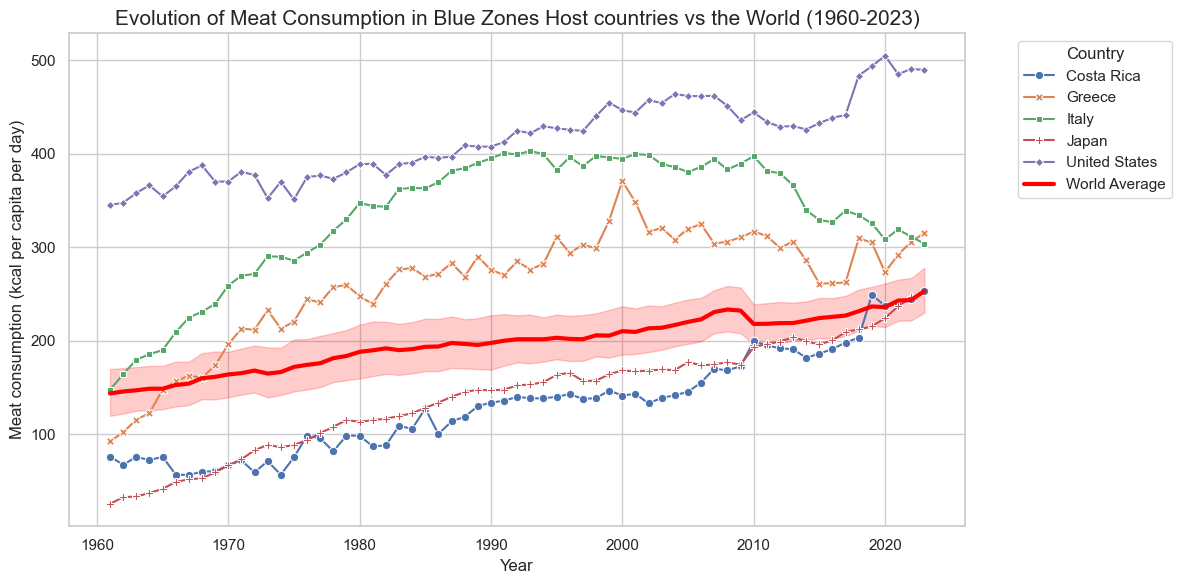

In [137]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plot = sns.lineplot(
    data=diet_df_bz, 
    x="Year", 
    y="Meat Consumption", 
    hue="Entity",       
    style="Entity",     
    markers=True,       
    dashes=False
)

sns.lineplot(
    data=diet_df_restofworld, 
    x="Year", 
    y="Meat Consumption", 
    color="red",     
    linewidth=3,      
    label="World Average", 
    zorder=5           
)

plt.title("Evolution of Meat Consumption in Blue Zones Host countries vs the World (1960-2023)", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Meat consumption (kcal per capita per day)", fontsize=12)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

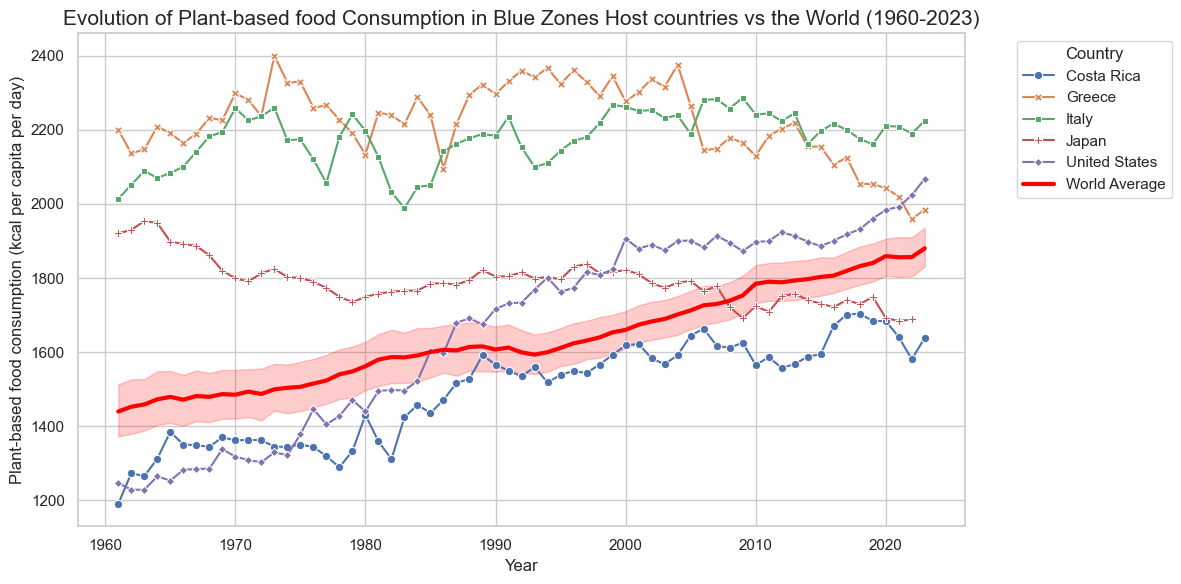

In [138]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plot = sns.lineplot(
    data=diet_df_bz, 
    x="Year", 
    y="Plant-based Consumption", 
    hue="Entity",       
    style="Entity",     
    markers=True,       
    dashes=False
)

sns.lineplot(
    data=diet_df_restofworld, 
    x="Year", 
    y="Plant-based Consumption", 
    color="red",     
    linewidth=3,      
    label="World Average", 
    zorder=5           
)

plt.title("Evolution of Plant-based food Consumption in Blue Zones Host countries vs the World (1960-2023)", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Plant-based food consumption (kcal per capita per day)", fontsize=12)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [139]:
diet_df_analysis_2023 = diet_df[diet_df["Year"]==2023].copy()
diet_df_analysis_2023["bz diet ratio"] = diet_df_analysis_2023[plant_cols].sum(axis=1)/diet_df_analysis_2023["Calories intake"]
diet_df_analysis_2023.sort_values(by="bz diet ratio", ascending=False)[["Entity","bz diet ratio"]][:10]

,Entity,bz diet ratio
8549,Nigeria,0.925607
6987,Madagascar,0.924752
4869,Guinea-Bissau,0.924398
7865,Mozambique,0.922992
6602,Liberia,0.913902
4554,Ghana,0.905125
3797,Ethiopia,0.903148
10282,Sierra Leone,0.889174
62,Afghanistan,0.887553
4806,Guinea,0.880675


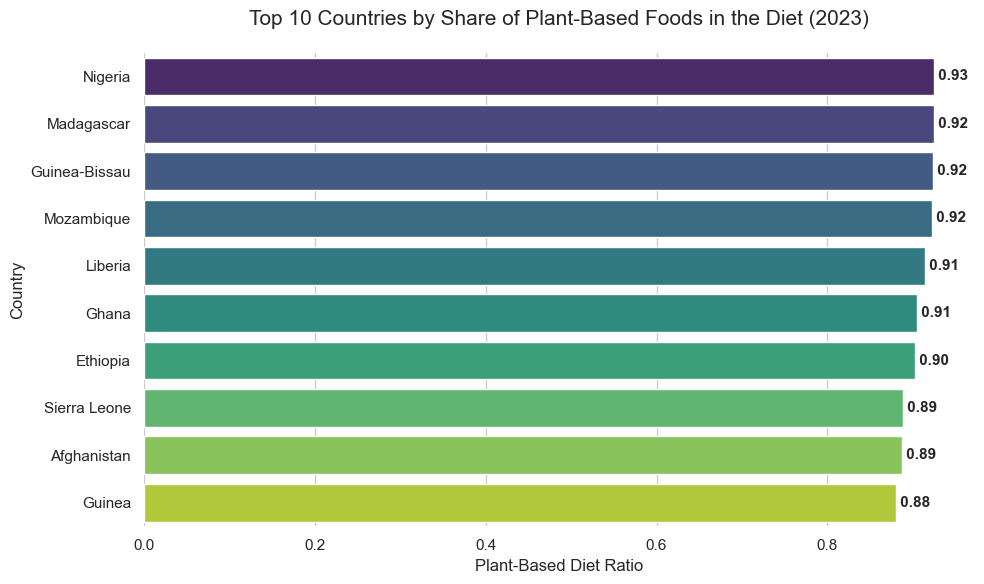

In [161]:

top_10_ratio = diet_df_analysis_2023.sort_values(by="bz diet ratio", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plot = sns.barplot(
    data=top_10_ratio, 
    x="bz diet ratio", 
    y="Entity", 
    palette="viridis",
    hue="Entity"
)

plt.title("Top 10 Countries by Share of Plant-Based Foods in the Diet (2023)", fontsize=15, pad=20)
plt.xlabel("Plant-Based Diet Ratio", fontsize=12)
plt.ylabel("Country", fontsize=12)

for i, value in enumerate(top_10_ratio["bz diet ratio"]):
    plot.text(value, i, f' {value:.2f}', va='center', fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [176]:
life_exp = pd.read_csv('../data/life-expectancy.csv')
life_exp = life_exp[life_exp["Entity"].isin(countries)]
plant_based_countries_2023 = list(set(top_10_ratio.Entity))
life_exp_2023 = life_exp[life_exp["Year"]==2023]
life_exp_2023['Rank'] = life_exp_2023['Life expectancy'].rank(
    method='min',   
    ascending=False 
).astype(int)
life_exp_2023[life_exp_2023["Entity"].isin(plant_based_countries_2023)][["Entity","Life expectancy","Rank"]]

,Entity,Life expectancy,Rank
73,Afghanistan,66.0346,177
5812,Ethiopia,67.3150,167
7010,Ghana,65.4979,181
7697,Guinea,60.7405,200
7771,Guinea-Bissau,64.0849,185
10835,Liberia,62.1625,194
11626,Madagascar,63.6317,190
13232,Mozambique,63.6111,191
14080,Nigeria,54.4623,207
17334,Sierra Leone,61.7858,196


In [168]:
life_exp_2023["Rank"].max()

np.int64(207)

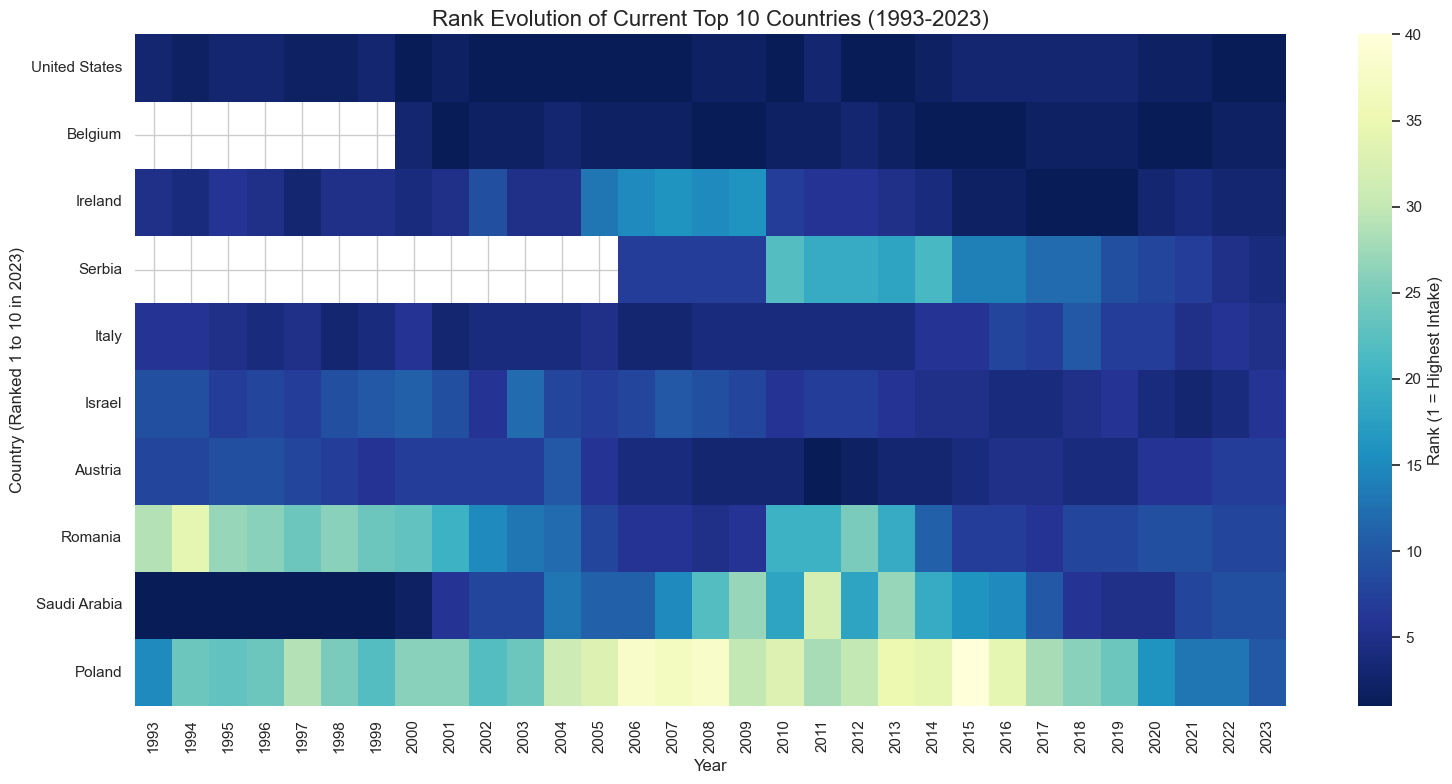

In [158]:
diet_df['Rank'] = diet_df.groupby('Year')["Calories intake"].rank(ascending=False, method='min')

max_year = diet_df['Year'].max()
min_year = max_year - 30
df_period = diet_df[diet_df['Year'] >= min_year]

top_10_entities = diet_df[diet_df['Year'] == max_year].nsmallest(10, 'Rank')['Entity']
df_top_10 = df_period[df_period['Entity'].isin(top_10_entities)]

df_pivot_rank = df_top_10.pivot(index='Entity', columns='Year', values='Rank')
df_pivot_rank = df_pivot_rank.loc[top_10_entities] 

plt.figure(figsize=(16, 8))
sns.heatmap(df_pivot_rank, 
            cmap='YlGnBu_r',   
            annot=False,        
            cbar_kws={'label': 'Rank (1 = Highest Intake)'})

plt.title(f"Rank Evolution of Current Top 10 Countries ({min_year}-{max_year})", fontsize=16)
plt.ylabel(f"Country (Ranked 1 to 10 in {max_year})")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [140]:
happiness_df = pd.read_csv("../data/happiness.csv")
happiness_df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.0,0.155,0.0,0.075,0.135,0.348
1,2023,143,Afghanistan,1.721,1.667,1.775,0.628,0.0,0.242,0.0,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.795,1.923,0.645,0.0,0.087,0.0,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.339,2.469,0.758,0.0,0.289,0.0,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.449,2.596,0.370,0.0,0.126,0.0,0.122,0.010,1.895


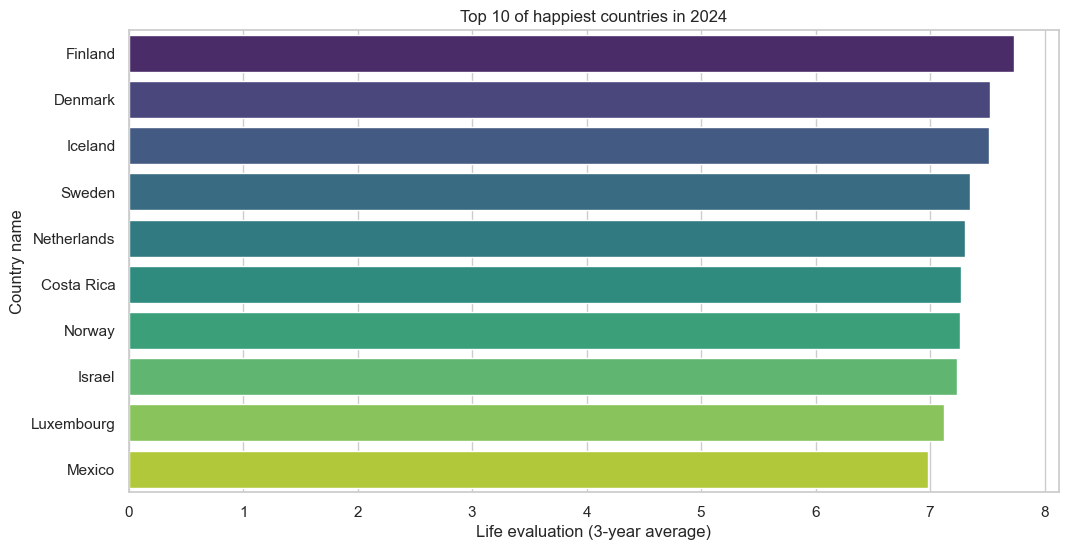

In [178]:
top_10 = happiness_df[happiness_df['Year'] == 2024].nlargest(10, 'Life evaluation (3-year average)')
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Life evaluation (3-year average)', y='Country name', hue="Country name",palette='viridis')
plt.title('Top 10 of happiest countries in 2024')
plt.show()

In [142]:
happiness_df_bz = happiness_df[happiness_df["Country name"].isin(blue_zones_countries)]
happiness_df_bz[happiness_df_bz["Year"]==2024][["Country name","Rank"]]

,Country name,Rank
390,Costa Rica,6
647,Greece,81
826,Italy,40
852,Japan,55
1866,United States,24


In [171]:
happiness_df_2023 = happiness_df[happiness_df["Year"]==2023]
happiness_df_2023_pb = happiness_df_2023[happiness_df_2023["Country name"].isin(plant_based_countries_2023)]
happiness_df_2023_pb[["Country name","Rank"]]

,Country name,Rank
1,Afghanistan,143
551,Ethiopia,130
635,Ghana,120
674,Guinea,97
991,Liberia,121
1042,Madagascar,123
1187,Mozambique,90
1288,Nigeria,102
1540,Sierra Leone,140


In [175]:
happiness_df_2023_pb["Rank"].max()

np.int64(143)